<a href="https://colab.research.google.com/github/ellenwang995/PriceAtThePump/blob/main/PumpPrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import numpy as np

In [71]:
#Upload data
df = pd.read_excel("/content/NY_GasPrice.xlsx")
df.head()

,Date,NY_Gas,WTI,Brent,PADD1
0,05/01/1987,0.917,19.44,18.58,88.1
1,06/01/1987,0.939,20.07,18.86,95.8
2,07/01/1987,0.968,21.34,19.86,93.6
3,08/01/1987,1.001,20.31,18.98,94.4
4,09/01/1987,1.004,19.53,18.31,88.0


In [72]:
#Set Date variable as a time variable
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df.dtypes

df = df.set_index('Date')
df.head()

,NY_Gas,WTI,Brent,PADD1
Date,,,,
1987-05-01,0.917,19.44,18.58,88.1
1987-06-01,0.939,20.07,18.86,95.8
1987-07-01,0.968,21.34,19.86,93.6
1987-08-01,1.001,20.31,18.98,94.4
1987-09-01,1.004,19.53,18.31,88.0


# 1987-2026 Correlation and Regression Analysis

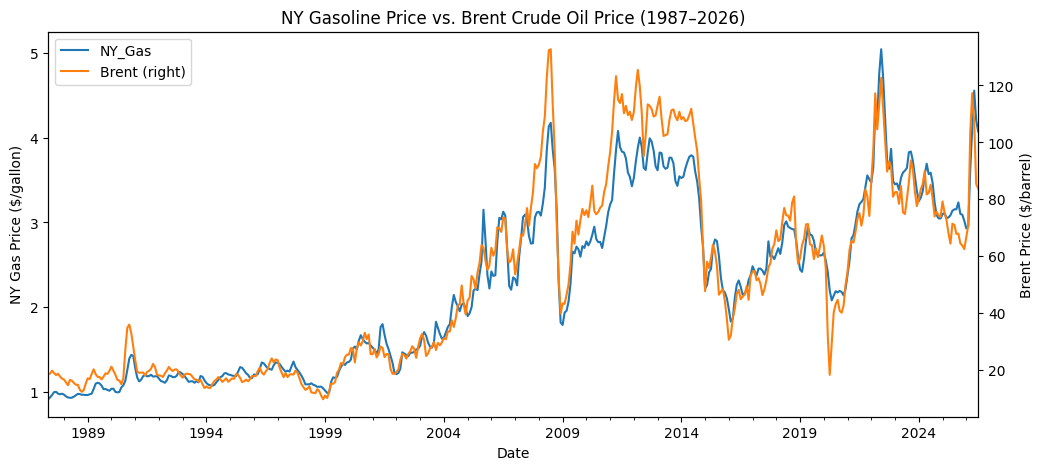

In [73]:
#plot data
ax = df[['NY_Gas', 'Brent']].plot(secondary_y='Brent', figsize=(12,5))

ax.set_title('NY Gasoline Price vs. Brent Crude Oil Price (1987–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.right_ax.set_ylabel('Brent Price ($/barrel)')

plt.show()

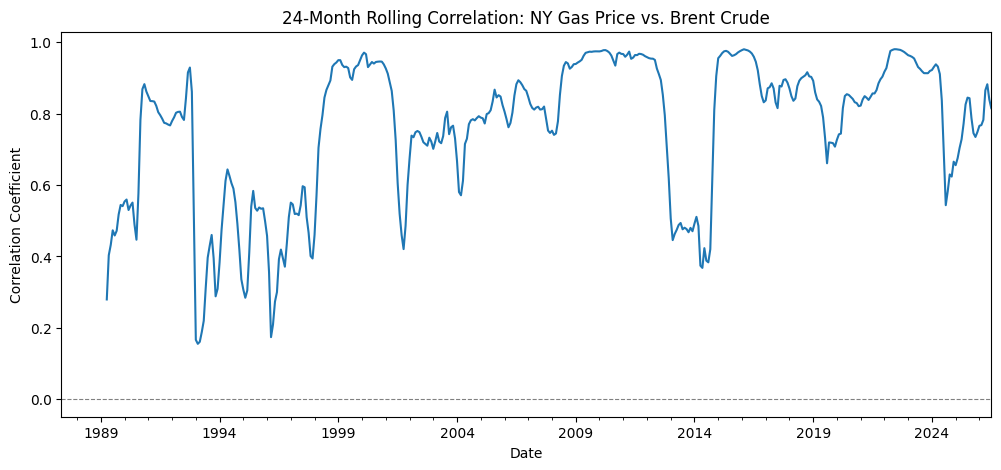

In [74]:
#correlation between WTI price and Gas Price
rolling_corr = df['NY_Gas'].rolling(24).corr(df['Brent'])

ax = rolling_corr.plot(figsize=(12,5))
ax.set_title('24-Month Rolling Correlation: NY Gas Price vs. Brent Crude')
ax.set_xlabel('Date')
ax.set_ylabel('Correlation Coefficient')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')  # reference line at 0

plt.show()

In [75]:
#Regression
X = sm.add_constant(df['Brent'])  # adds intercept term
y = df['NY_Gas']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 NY_Gas   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     7281.
Date:                Tue, 08 Sep 2026   Prob (F-statistic):          8.47e-288
Time:                        01:43:27   Log-Likelihood:                -8.7125
No. Observations:                 471   AIC:                             21.42
Df Residuals:                     469   BIC:                             29.73
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7116      0.021     33.603      0.0

# 2020-2026 Correlation and Regression Analysis

In [76]:
df_post2020 = df.loc['2020-01-01':'2026-12-31']
df_post2025 = df.loc['2025-01-01':'2026-12-31']

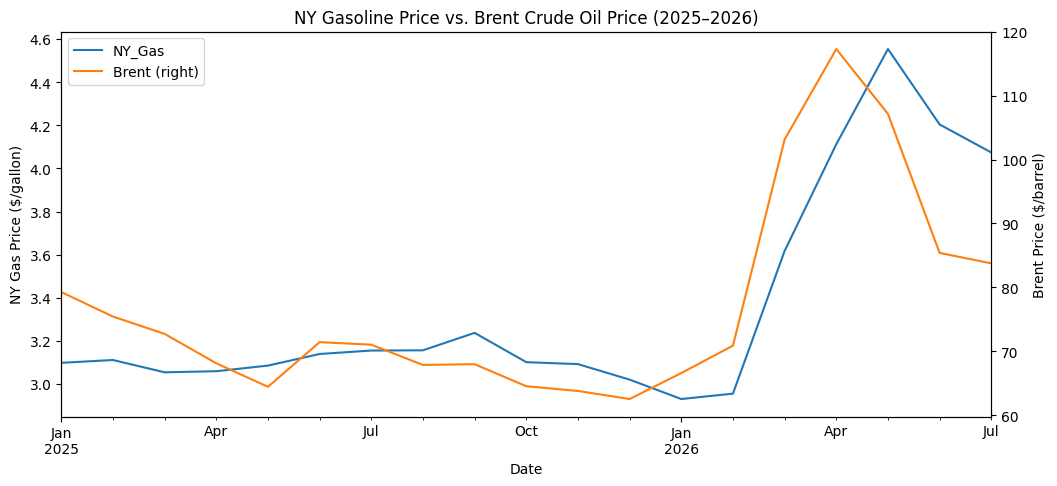

In [77]:
ax = df_post2025[['NY_Gas', 'Brent']].plot(secondary_y='Brent', figsize=(12,5))

ax.set_title('NY Gasoline Price vs. Brent Crude Oil Price (2025–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.right_ax.set_ylabel('Brent Price ($/barrel)')

plt.show()

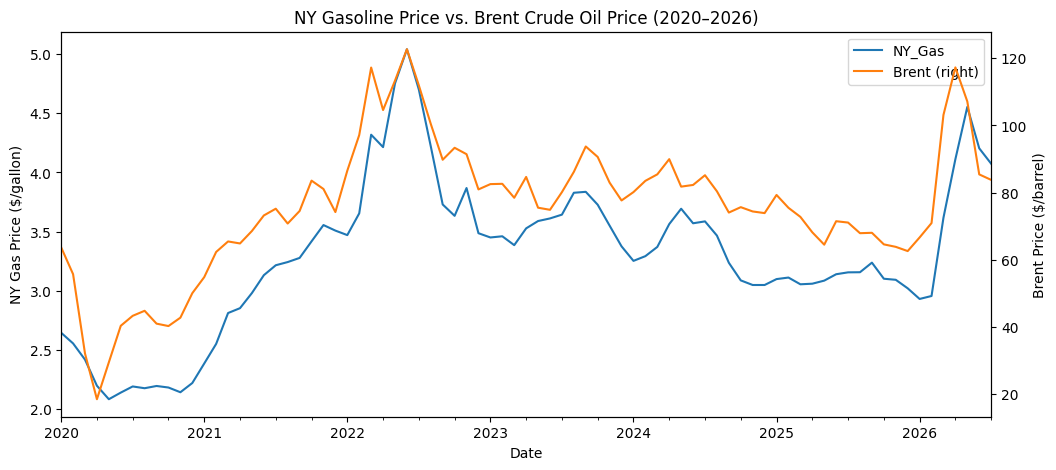

In [78]:
ax = df_post2020[['NY_Gas', 'Brent']].plot(secondary_y='Brent', figsize=(12,5))

ax.set_title('NY Gasoline Price vs. Brent Crude Oil Price (2020–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.right_ax.set_ylabel('Brent Price ($/barrel)')

plt.show()

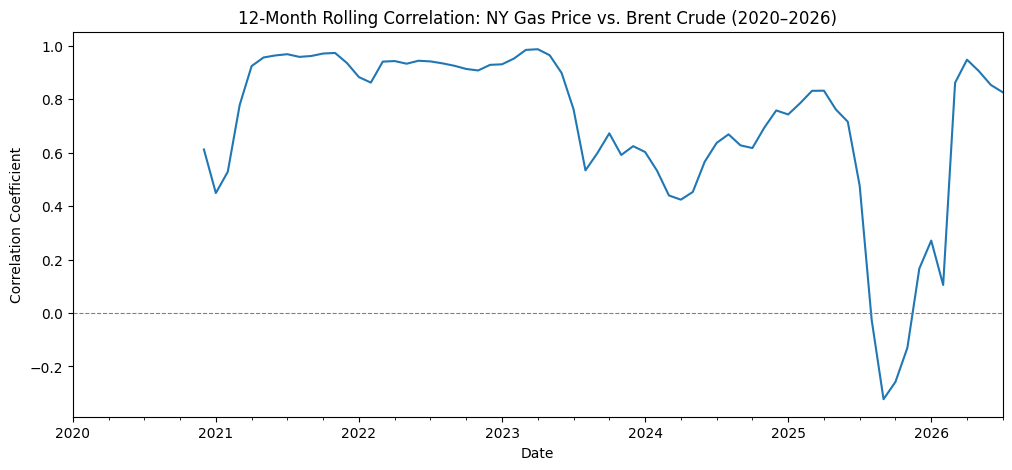

In [79]:
rolling_corr_post2020 = df_post2020['NY_Gas'].rolling(12).corr(df_post2020['Brent'])

ax = rolling_corr_post2020.plot(figsize=(12,5))
ax.set_title('12-Month Rolling Correlation: NY Gas Price vs. Brent Crude (2020–2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Correlation Coefficient')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.show()

In [80]:
X_post2020 = sm.add_constant(df_post2020['Brent'])
y_post2020 = df_post2020['NY_Gas']

model_post2020 = sm.OLS(y_post2020, X_post2020, missing='drop').fit()
print(model_post2020.summary())

                            OLS Regression Results                            
Dep. Variable:                 NY_Gas   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     549.3
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           8.70e-37
Time:                        01:43:28   Log-Likelihood:                 5.9849
No. Observations:                  79   AIC:                            -7.970
Df Residuals:                      77   BIC:                            -3.231
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0361      0.100     10.402      0.0

# Rolling Regression Coefficient

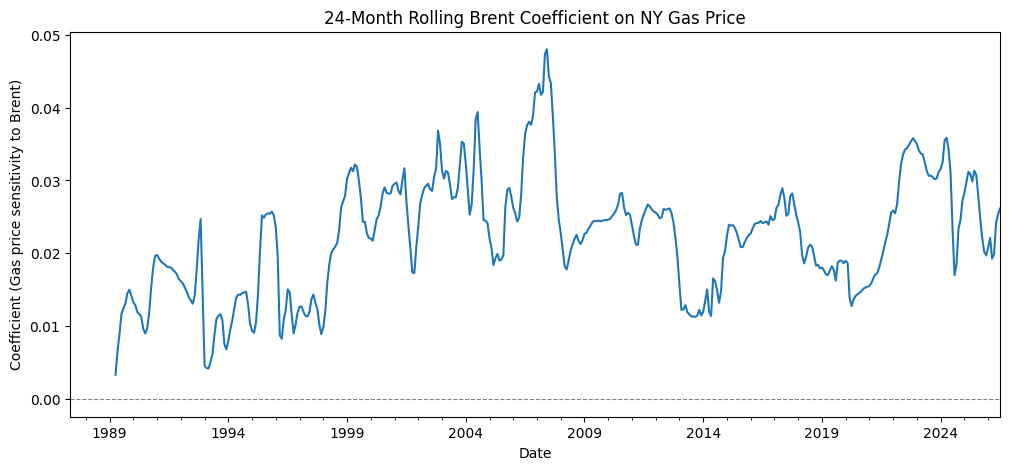

In [81]:
X = sm.add_constant(df['Brent'])
y = df['NY_Gas']
window = 24
rolling_model = RollingOLS(y, X, window=window).fit()
rolling_coef = rolling_model.params['Brent']

rolling_coef.plot(figsize=(12,5), title=f'{window}-Month Rolling Brent Coefficient on NY Gas Price')
plt.xlabel('Date')
plt.ylabel('Coefficient (Gas price sensitivity to Brent)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.show()

/tmp/ipykernel_2819/785434137.py:7: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(rolling_const.index, np.poly1d(np.polyfit(rolling_const.dropna().index.map(pd.Timestamp.toordinal), rolling_const.dropna(), 1))(rolling_const.index.map(pd.Timestamp.toordinal)), color='red', linestyle='--')


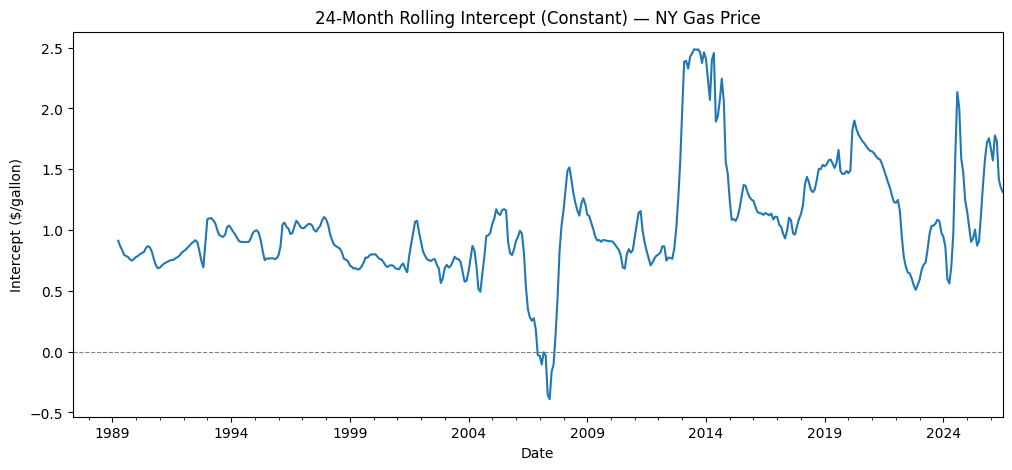

In [98]:
rolling_const = rolling_model.params['const']

rolling_const.plot(figsize=(12,5), title=f'{window}-Month Rolling Intercept (Constant) — NY Gas Price')
plt.xlabel('Date')
plt.ylabel('Intercept ($/gallon)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.show()

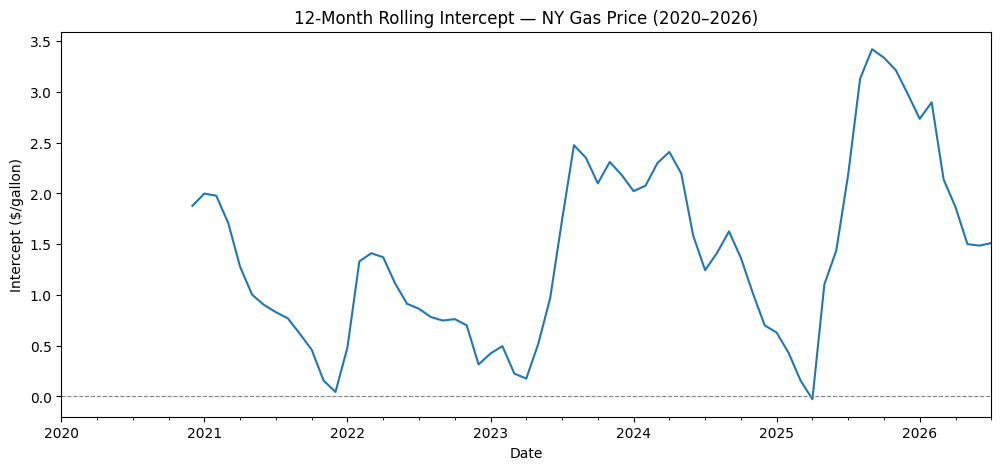

In [83]:
window_post2020 = 12
rolling_model_post2020 = RollingOLS(y_post2020, X_post2020, window=window_post2020).fit()

rolling_const_post2020 = rolling_model_post2020.params['const']

rolling_const_post2020.plot(figsize=(12,5), title=f'{window_post2020}-Month Rolling Intercept — NY Gas Price (2020–2026)')
plt.xlabel('Date')
plt.ylabel('Intercept ($/gallon)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.show()

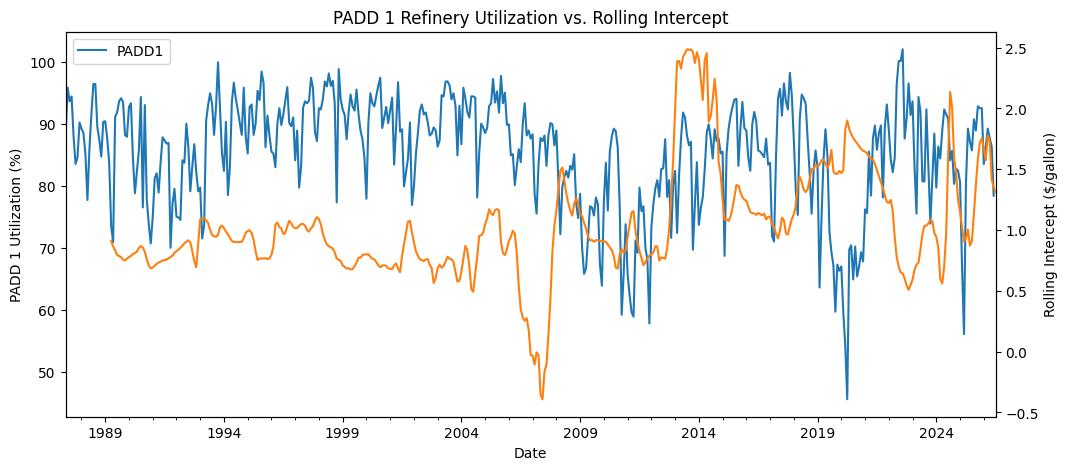

In [87]:
ax = df[['PADD1']].plot(figsize=(12,5))
rolling_const.plot(ax=ax, secondary_y=True, label='Rolling Intercept')
ax.set_title('PADD 1 Refinery Utilization vs. Rolling Intercept')
ax.set_ylabel('PADD 1 Utilization (%)')
ax.right_ax.set_ylabel('Rolling Intercept ($/gallon)')
plt.show()

In [92]:
# Full-period correlation
corr_full = df['PADD1'].corr(rolling_const)

# 2024-2026 subset correlation
corr_recent = df.loc['2024-01-01':'2026-12-31', 'PADD1'].corr(
    rolling_const.loc['2024-01-01':'2026-12-31']
)

# Summary table
summary_table = pd.DataFrame({
    'Period': ['Full History', '2024–2026'],
    'Correlation (Utilization vs. Intercept)': [corr_full, corr_recent]
})

summary_table


,Period,Correlation (Utilization vs. Intercept)
0,Full History,-0.241872
1,2024–2026,0.202736


# % Change Analysis

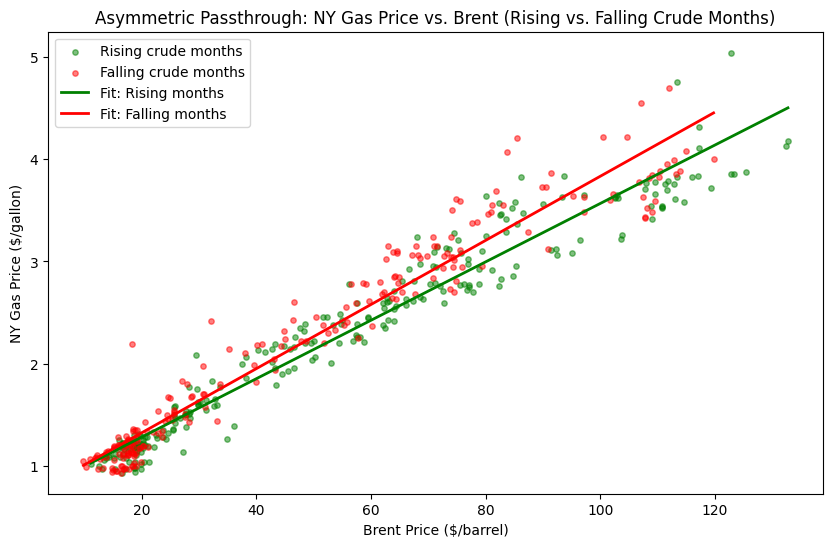

In [95]:
# Asymmetric Passthrough
# 1. Compute month-over-month change in crude (Brent, or swap in WTI)
df['Brent_change'] = df['Brent'].diff()

# 2. Split into rising vs. falling months
rising = df[df['Brent_change'] > 0].copy()
falling = df[df['Brent_change'] < 0].copy()

# 3. Regression during crude RISING months
X_rising = sm.add_constant(rising['Brent'])
y_rising = rising['NY_Gas']
model_rising = sm.OLS(y_rising, X_rising, missing='drop').fit()

# 4. Regression during crude FALLING months
X_falling = sm.add_constant(falling['Brent'])
y_falling = falling['NY_Gas']
model_falling = sm.OLS(y_falling, X_falling, missing='drop').fit()

# 5. Compare results side by side
comparison = pd.DataFrame({
    'Rising Crude Months': [model_rising.params['Brent'], model_rising.rsquared, len(rising)],
    'Falling Crude Months': [model_falling.params['Brent'], model_falling.rsquared, len(falling)]
}, index=['WTI/Brent Coefficient', 'R-squared', 'N (months)'])

fig, ax = plt.subplots(figsize=(10,6))

# Scatter the actual data points, colored by direction
ax.scatter(rising['Brent'], rising['NY_Gas'], color='green', alpha=0.5, label='Rising crude months', s=15)
ax.scatter(falling['Brent'], falling['NY_Gas'], color='red', alpha=0.5, label='Falling crude months', s=15)

# Overlay the two fitted regression lines
brent_range_rising = pd.Series(sorted(rising['Brent'].dropna().unique()))
brent_range_falling = pd.Series(sorted(falling['Brent'].dropna().unique()))

pred_rising = model_rising.predict(sm.add_constant(brent_range_rising))
pred_falling = model_falling.predict(sm.add_constant(brent_range_falling))

ax.plot(brent_range_rising, pred_rising, color='green', linewidth=2, label='Fit: Rising months')
ax.plot(brent_range_falling, pred_falling, color='red', linewidth=2, label='Fit: Falling months')

ax.set_title('Asymmetric Passthrough: NY Gas Price vs. Brent (Rising vs. Falling Crude Months)')
ax.set_xlabel('Brent Price ($/barrel)')
ax.set_ylabel('NY Gas Price ($/gallon)')
ax.legend()

plt.show()

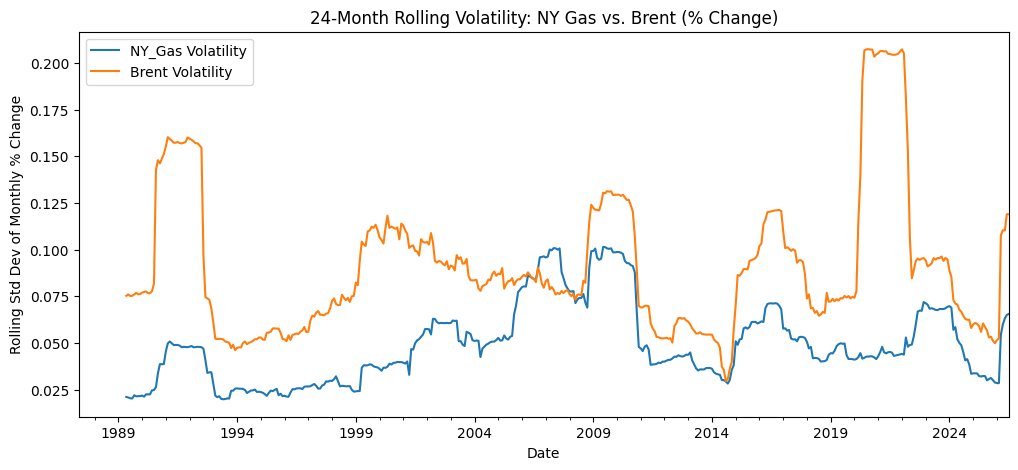

In [88]:
gas_pct_change = df['NY_Gas'].pct_change()
brent_pct_change = df['Brent'].pct_change()

# Rolling 24-month standard deviation of those % changes
window = 24
gas_vol = gas_pct_change.rolling(window).std()
brent_vol = brent_pct_change.rolling(window).std()

# Plot both together
ax = gas_vol.plot(figsize=(12,5), label='NY_Gas Volatility')
brent_vol.plot(ax=ax, label='Brent Volatility')

ax.set_title(f'{window}-Month Rolling Volatility: NY Gas vs. Brent (% Change)')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Std Dev of Monthly % Change')
ax.legend()

plt.show()